<a href="https://colab.research.google.com/github/dagudelo30/Series-de-tiempo---Javeriana-Cali/blob/main/hwt/suavización_exponencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pronósticos basados en series de tiempo 

## Diego Fernando Agudelo
## Universidad Javeriana-Cali
## diegoagudelo30@gmail.com



## **1. Carga de paquetes**

In [121]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error


Este documento presenta una breve introducción a la construcción de objetos de series de tiempo y el cálculo de pronósticos con modelos de suavización.

Para este ejercicio emplearemos la información disponible en el archivo datosEmpleo.xlsx. En ese archivo econtrarán la tasa de desempleo mensual de las 13 principales ciudades en Colombia (TD_13ciudades). El archivo también contiene series mensuales para las 13 principales ciudades de Colombia el número de ocupados en miles de personas (Ocupados), los desocupados (Desocupados) y los inactivos (Inactivos).

## **2. Carga de datos**

Nuestra primera tarea será leer el archivo de Excel. Para eso podemos emplear el paquete Pandas. Carguemos los datos en un objeto que denominaremos data.

In [122]:
data = pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


En este caso los datos fueron leídos como un data frame y adicionalmente la columna "mes" fue seleccionada como indice, con el dataframe de esta forma sera más facil trabajar las series de tiempo.

A continuación se gráfica la tasa de desempleo.



(222, 4)


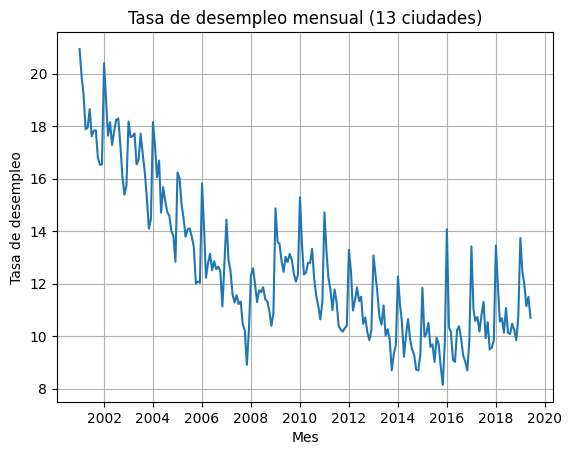

In [123]:
# imprimiendo el tamano del dataframe
print(data.shape)

# Graficando los datos
plt.title("Tasa de desempleo mensual (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Tasa de desempleo")
plt.plot(data[["TD_13ciudades"]])
plt.grid()
plt.show()

## **3. Pronosticando metodos de suavización**

Antes de continuar es importante guardar una parte de la muestra para evaluar el comportamiento de los modelos por fuera de muestra (out-of-sample). Guardemos un año de datos.

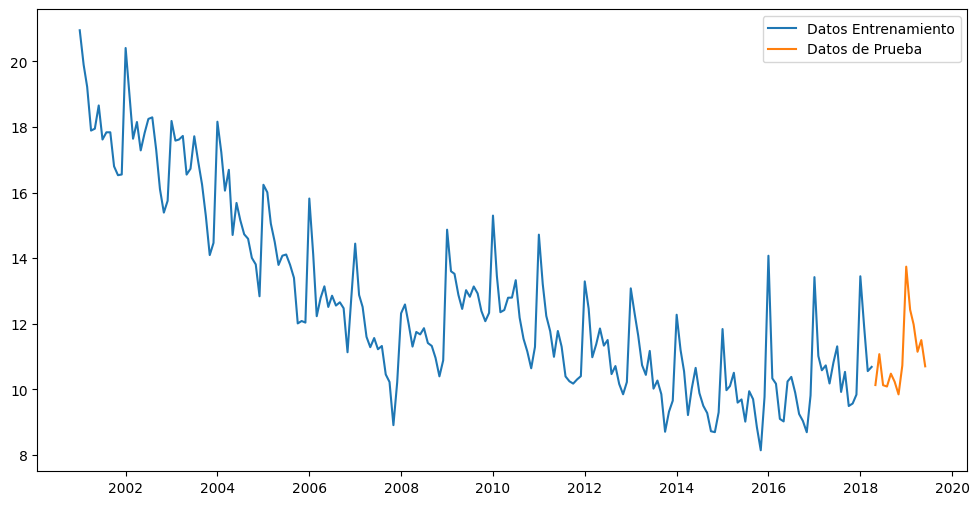

In [124]:
train_len = 208
train_td = data[["TD_13ciudades"]][:train_len]
test_td = data[["TD_13ciudades"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td,label="Datos de Prueba")
plt.legend()
plt.show()

In [125]:
train_td

,TD_13ciudades
mes,
2001-01-01,20.946380
2001-02-01,19.894213
2001-03-01,19.221565
2001-04-01,17.888575
2001-05-01,17.945654
...,...
2017-12-01,9.837395
2018-01-01,13.446245
2018-02-01,11.874973


In [126]:
test_td

,TD_13ciudades
mes,
2018-05-01,10.129211
2018-06-01,11.071347
2018-07-01,10.125100
2018-08-01,10.085244
2018-09-01,10.476567
2018-10-01,10.230811
2018-11-01,9.844539
2018-12-01,10.725865
2019-01-01,13.739328


### **3.1 Suavizacion Exponencial Simple**

In [127]:
# Build model.
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="add")#,trend="add",seasonal="mul" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds = pd.concat([limits, conf_forecast], axis = 1)
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

            Point_forecast  lower_95   upper_95
2018-05-01       10.959788  8.650409  13.269166
2018-06-01       10.959788  8.505554  13.414021
2018-07-01       10.959788  8.368785  13.550791
2018-08-01       10.959788  8.238882  13.680694
2018-09-01       10.959788  8.114904  13.804671
2018-10-01       10.959788  7.996109  13.923467
2018-11-01       10.959788  7.881894  14.037681
2018-12-01       10.959788  7.771769  14.147806
2019-01-01       10.959788  7.665324  14.254252
2019-02-01       10.959788  7.562211  14.357365
2019-03-01       10.959788  7.462137  14.457439
2019-04-01       10.959788  7.364848  14.554728
2019-05-01       10.959788  7.270123  14.649453
2019-06-01       10.959788  7.177770  14.741806


c:\Users\karol\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


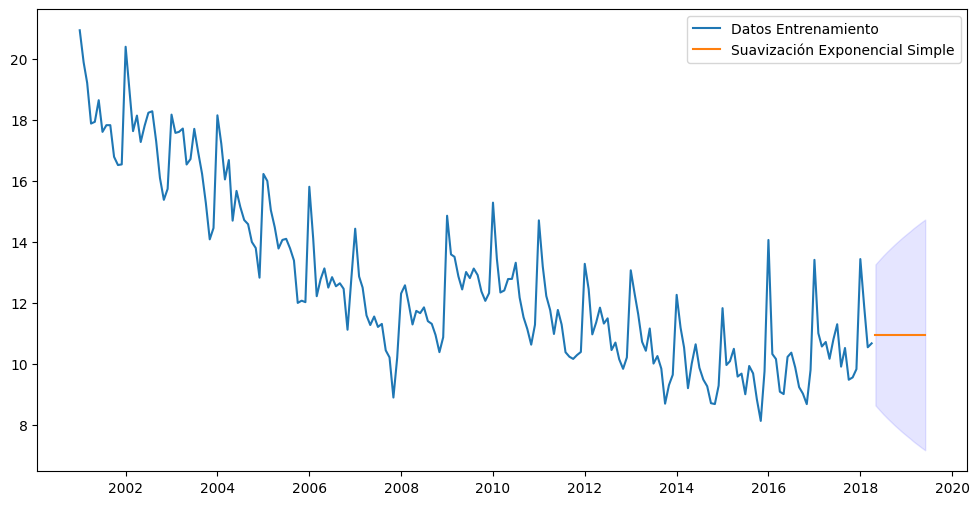

In [128]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds['Point_forecast'],label="Suavización Exponencial Simple")
plt.fill_between(preds.index ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

En esta caso el α estimado es 0.3596639.Y el RMSE en la muestra de evaluación es 1.05

In [129]:
ets_result.alpha

np.float64(0.35969957559668314)

In [130]:
rmse = np.sqrt(mean_squared_error(test_td,point_forecast ))
print(rmse)

1.0532673904186352


### **3.2 Suavizacion Exponencial Lineal (Holt)**

In [131]:
# Build model.
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="mul",trend="mul")#,seasonal="mul" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_holt = pd.concat([limits, conf_forecast], axis = 1)
preds_holt.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_holt)

            Point_forecast  lower_95   upper_95
2018-05-01       10.660587  8.661426  12.705939
2018-06-01       10.632890  8.573757  12.866620
2018-07-01       10.605265  8.345440  12.644525
2018-08-01       10.577711  8.408453  12.752290
2018-09-01       10.550230  8.347611  12.908461
2018-10-01       10.522819  8.383213  12.911801
2018-11-01       10.495480  8.297787  12.702480
2018-12-01       10.468212  8.396352  12.874609
2019-01-01       10.441014  8.247379  12.790225
2019-02-01       10.413888  8.245225  13.023379
2019-03-01       10.386832  8.204276  12.670428
2019-04-01       10.359846  8.175113  13.005381
2019-05-01       10.332930  8.204226  12.792356
2019-06-01       10.306084  8.032148  12.878918


c:\Users\karol\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


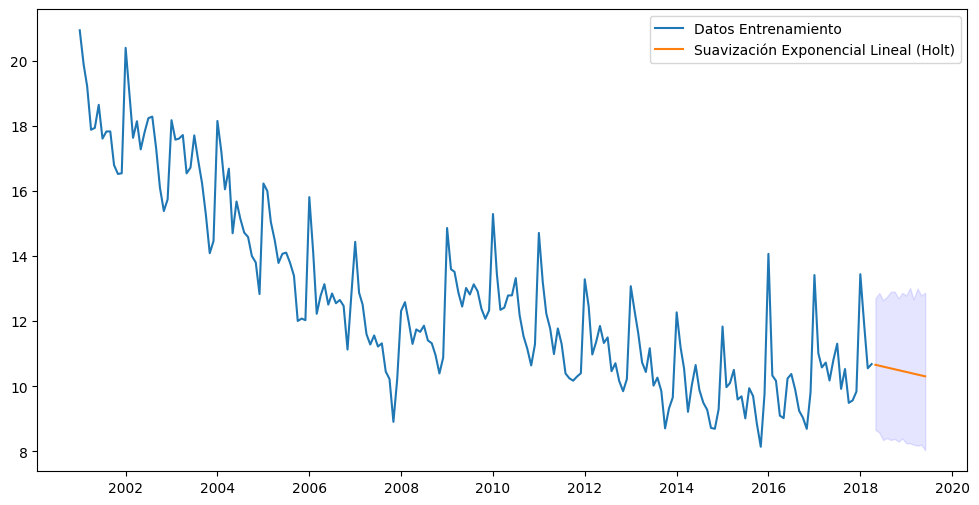

In [132]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_holt['Point_forecast'],label="Suavización Exponencial Lineal (Holt)")
plt.fill_between(preds_holt.index ,preds_holt['lower_95'], preds_holt['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

En esta caso el α estimado es 0.17153975893378887 y el β estimado es 1.7153975893378887$^{-5}$. Y el RMSE en la muestra de evaluación es 1.22814498296009.

In [133]:
print(ets_result.alpha,ets_result.beta)

0.17153909365393913 1.7153909365393913e-05


In [134]:
rmse_holt = np.sqrt(mean_squared_error(test_td,preds_holt['Point_forecast']))
print(rmse_holt)

1.228145801463044


### **3.3 Suavizacion Exponencial Lineal de Winters (Holt-Winters)**

In [135]:
# Build model
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="add",trend="add",seasonal="add" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_add = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add)

            Point_forecast   lower_95   upper_95
2018-05-01       10.297371   9.251560  11.343183
2018-06-01       10.674325   9.532337  11.816313
2018-07-01       10.565100   9.334412  11.795788
2018-08-01       10.226589   8.913162  11.540017
2018-09-01        9.946370   8.555100  11.337640
2018-10-01        9.282632   7.817635  10.747628
2018-11-01        8.875136   7.339935  10.410336
2018-12-01        9.376551   7.774206  10.978895
2019-01-01       12.534208  10.867410  14.201006
2019-02-01       11.193066   9.464203  12.921928
2019-03-01       10.434228   8.645441  12.223015
2019-04-01       10.158460   8.311680  12.005240
2019-05-01        9.827778   7.924747  11.730809
2019-06-01       10.204732   8.247068  12.162395


c:\Users\karol\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


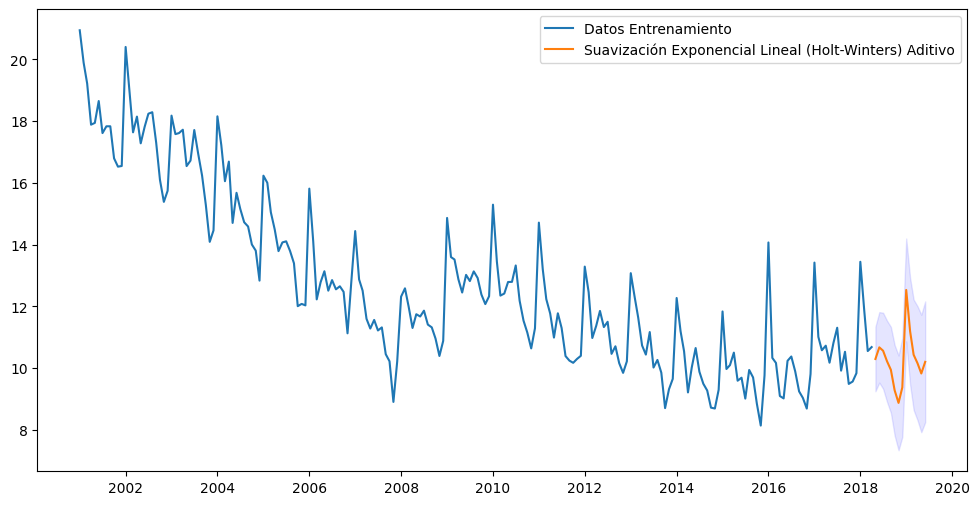

In [136]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_hw_add['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Aditivo")
plt.fill_between(preds_hw_add.index ,preds_hw_add['lower_95'], preds_hw_add['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [137]:
print(ets_result.alpha,ets_result.beta,ets_result.gamma)

0.43857184633310375 4.385718463331038e-05 5.6142815366689624e-05


In [138]:
rmse_hw_add = np.sqrt(mean_squared_error(test_td,preds_hw_add['Point_forecast']))
print(rmse_hw_add)

0.9893610351254504


In [139]:
# Build model.
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="add",trend=None,seasonal="mul" , )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_mul = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_mul)

            Point_forecast   lower_95   upper_95
2018-05-01       10.433036   9.256658  11.478387
2018-06-01       10.981856   9.704306  12.125792
2018-07-01       10.779516   9.410363  12.044344
2018-08-01       10.380956   8.995383  11.622725
2018-09-01       10.300534   8.755052  11.776616
2018-10-01        9.708898   8.173859  11.140683
2018-11-01        9.565507   7.928457  11.029440
2018-12-01       10.265134   8.535364  11.908874
2019-01-01       13.399531  11.277504  15.436837
2019-02-01       11.447407   9.432721  13.473108
2019-03-01       10.843306   8.802871  12.739909
2019-04-01       10.618172   8.679655  12.539164
2019-05-01       10.433036   8.420416  12.473996
2019-06-01       10.981856   8.782370  13.071391


c:\Users\karol\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


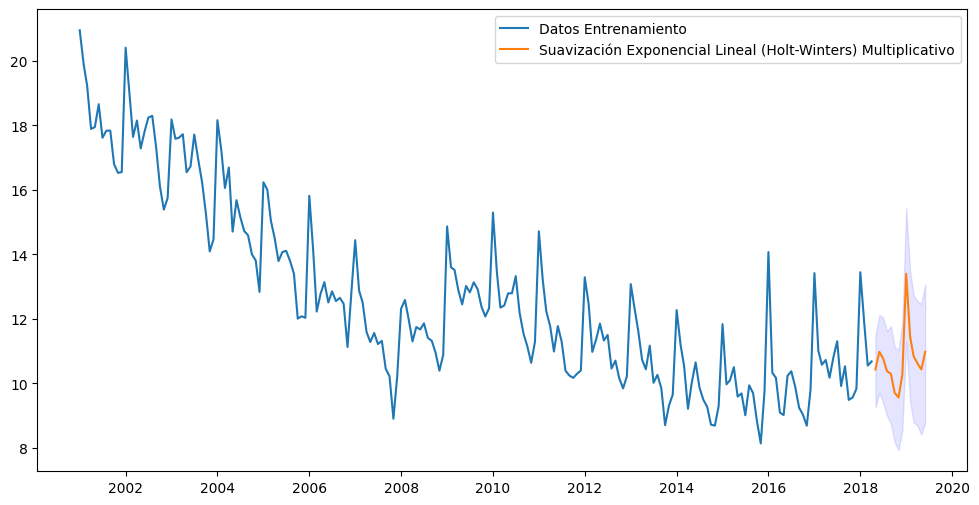

In [140]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_hw_mul['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Multiplicativo")
plt.fill_between(preds_hw_mul.index ,preds_hw_mul['lower_95'], preds_hw_mul['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [141]:
print(ets_result.alpha,ets_result.gamma)

0.4314982974685176 0.1609708946436222


In [142]:
rmse_hw_mul = np.sqrt(mean_squared_error(test_td,preds_hw_mul['Point_forecast']))
print(rmse_hw_mul)

0.601249106131057


## **4. Pronosticando con todo el data set**

In [143]:
final_model = ETSModel(endog=data["TD_13ciudades"],error="add",trend=None,seasonal="mul")
final_model_fit = final_model.fit_constrained({'smoothing_level': 0.43149852724451526,'smoothing_seasonal':0.16097100344659288})

print(final_model_fit.alpha)
print(final_model_fit.gamma)


0.43149852724451526
0.16097100344659288


c:\Users\karol\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [144]:
point_forecast=final_model_fit.forecast(6)

ci = final_model_fit.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_final= pd.concat([limits, conf_forecast], axis = 1)
preds_final.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_final)

            Point_forecast  lower_95   upper_95
2019-07-01       11.046643  9.904605  12.161136
2019-08-01       10.739259  9.583935  11.976925
2019-09-01       10.735391  9.511125  12.005559
2019-10-01       10.144408  8.802658  11.518216
2019-11-01        9.914408  8.488729  11.296903
2019-12-01       10.658186  9.126552  12.270570


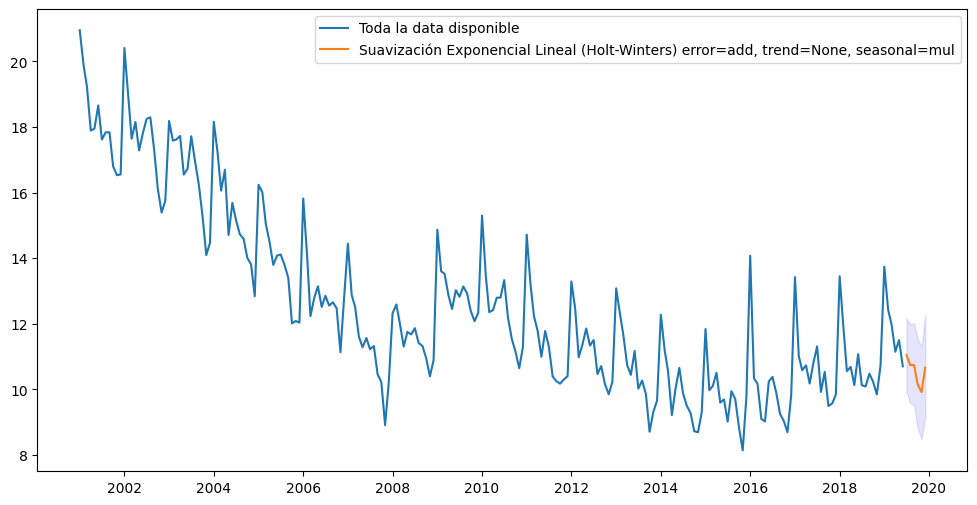

In [145]:
fig = plt.figure(figsize=(12, 6))
plt.plot(data["TD_13ciudades"],label="Toda la data disponible")
plt.plot(preds_final['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) error=add, trend=None, seasonal=mul")
plt.fill_between(preds_final.index ,preds_final['lower_95'], preds_final['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

## **5. Ejercicio en Clase: Pronóstico de Ocupados**

**Objetivo**: Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encontrar el mejor pronóstico para los próximos 6 meses mediante comparación rigurosa de tres variantes de suavización exponencial, validando con protocolo train/test de 6 periodos.

### 5.1 Descripción de la Base de Datos - Variable "Ocupados"

DESCRIPCIÓN DE LA BASE DE DATOS - VARIABLE 'OCUPADOS'

Período de datos: 2001-01-01 a 2019-06-01
Total de observaciones: 222
Frecuencia: Mensual

Estadísticas descriptivas:
           Ocupados
count    222.000000
mean    9160.852009
std     1295.492800
min     6923.604000
25%     7971.103000
50%     9139.064500
75%    10458.510250
max    11037.199000


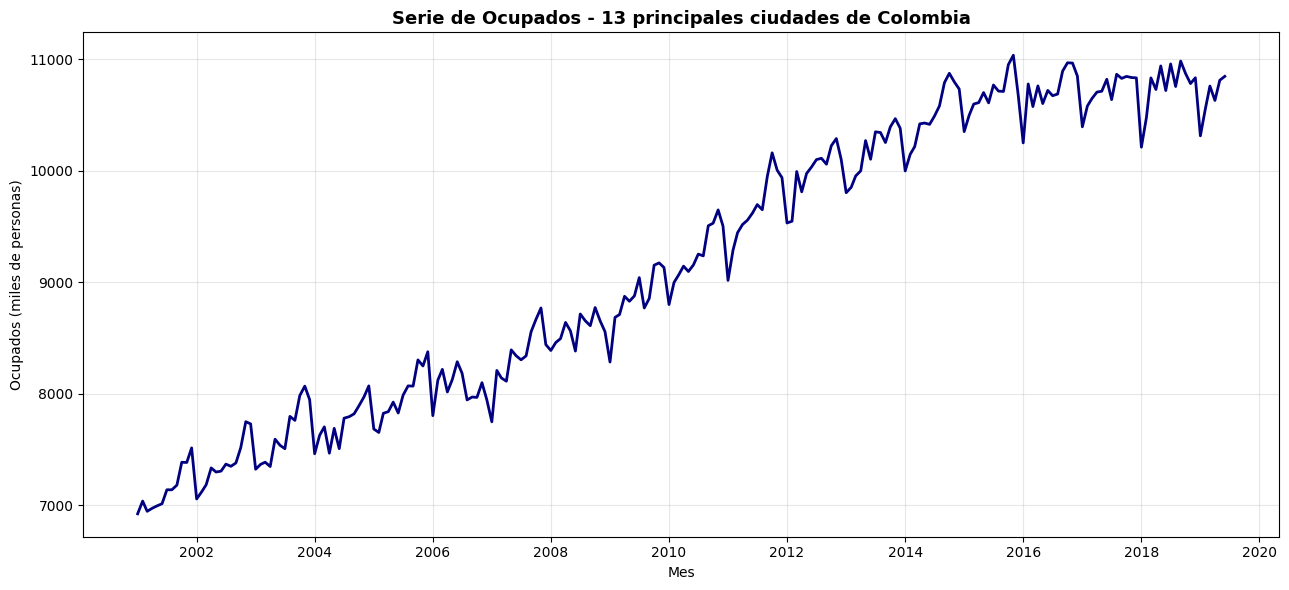

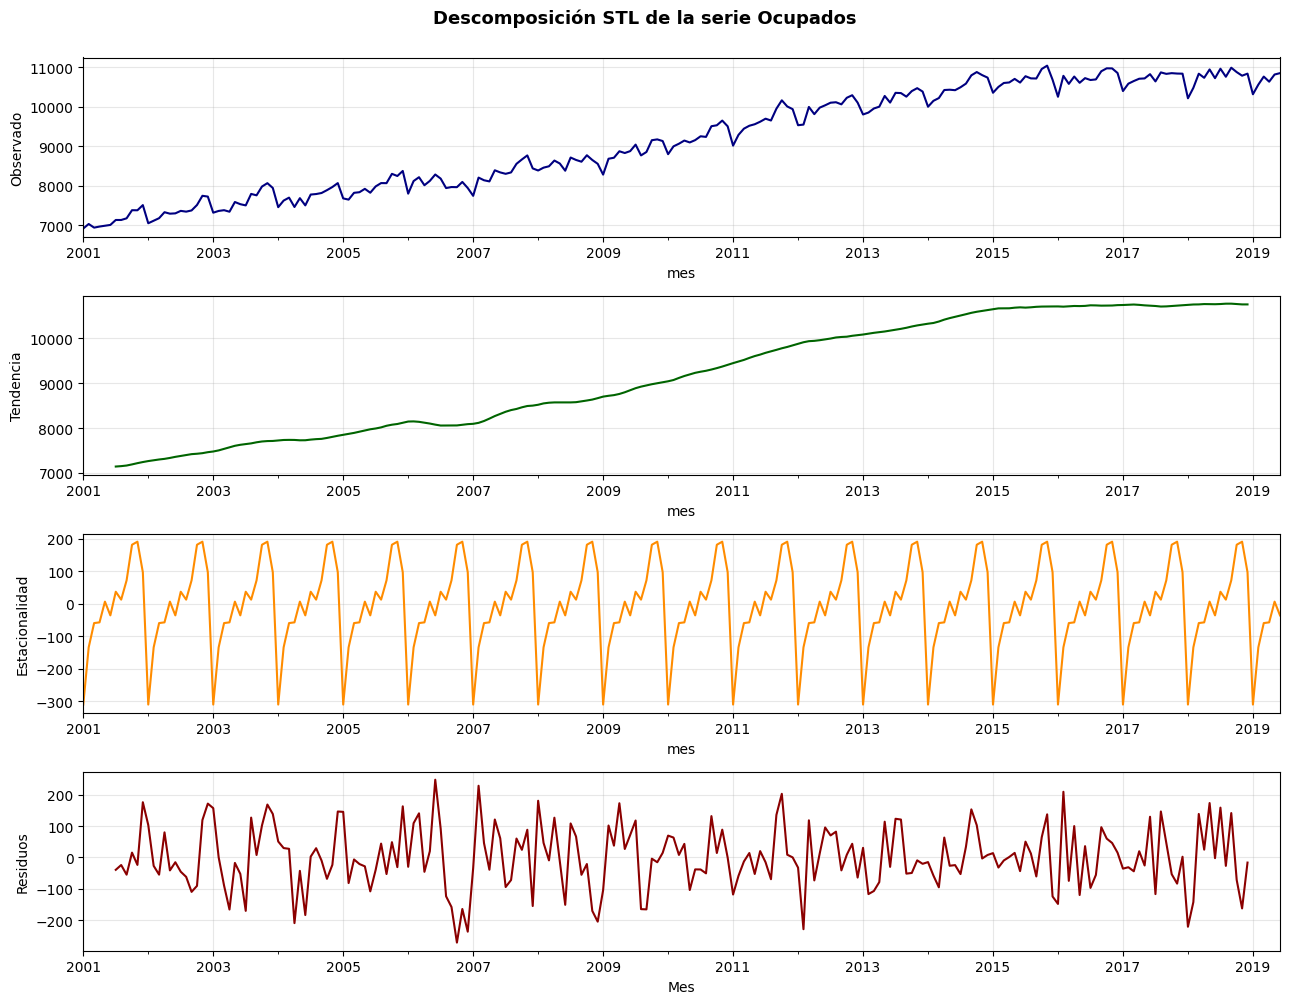


Presencia de tendencia: SÍ (crecimiento general)
Presencia de estacionalidad: SÍ (patrón anual recurrente)


In [146]:
# Exploración de la variable Ocupados
print("=" * 70)
print("DESCRIPCIÓN DE LA BASE DE DATOS - VARIABLE 'OCUPADOS'")
print("=" * 70)

ocupados = data[["Ocupados"]].copy()

print(f"\nPeríodo de datos: {ocupados.index[0].date()} a {ocupados.index[-1].date()}")
print(f"Total de observaciones: {len(ocupados)}")
print(f"Frecuencia: Mensual")
print(f"\nEstadísticas descriptivas:")
print(ocupados.describe())

# Gráfico de la serie completa
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(ocupados, linewidth=2, color='navy')
ax.set_title("Serie de Ocupados - 13 principales ciudades de Colombia", fontsize=13, fontweight='bold')
ax.set_xlabel("Mes")
ax.set_ylabel("Ocupados (miles de personas)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Verificar presencia de tendencia y estacionalidad
from statsmodels.tsa.seasonal import seasonal_decompose

# Usar una periodicidad de 12 meses (anual)
descomposicion = seasonal_decompose(ocupados, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10))
descomposicion.observed.plot(ax=axes[0], color='navy')
axes[0].set_ylabel('Observado')
axes[0].grid(True, alpha=0.3)

descomposicion.trend.plot(ax=axes[1], color='darkgreen')
axes[1].set_ylabel('Tendencia')
axes[1].grid(True, alpha=0.3)

descomposicion.seasonal.plot(ax=axes[2], color='darkorange')
axes[2].set_ylabel('Estacionalidad')
axes[2].grid(True, alpha=0.3)

descomposicion.resid.plot(ax=axes[3], color='darkred')
axes[3].set_ylabel('Residuos')
axes[3].set_xlabel('Mes')
axes[3].grid(True, alpha=0.3)

plt.suptitle("Descomposición STL de la serie Ocupados", fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nPresencia de tendencia: SÍ (crecimiento general)")
print("Presencia de estacionalidad: SÍ (patrón anual recurrente)")

### 5.2 Protocolo de Validación: División Train/Test (Últimos 6 meses como Test)

PROTOCOLO DE VALIDACIÓN

Conjunto de entrenamiento: 216 observaciones
Período: 2001-01-01 a 2018-12-01

Conjunto de prueba: 6 observaciones (6 meses)
Período: 2019-01-01 a 2019-06-01


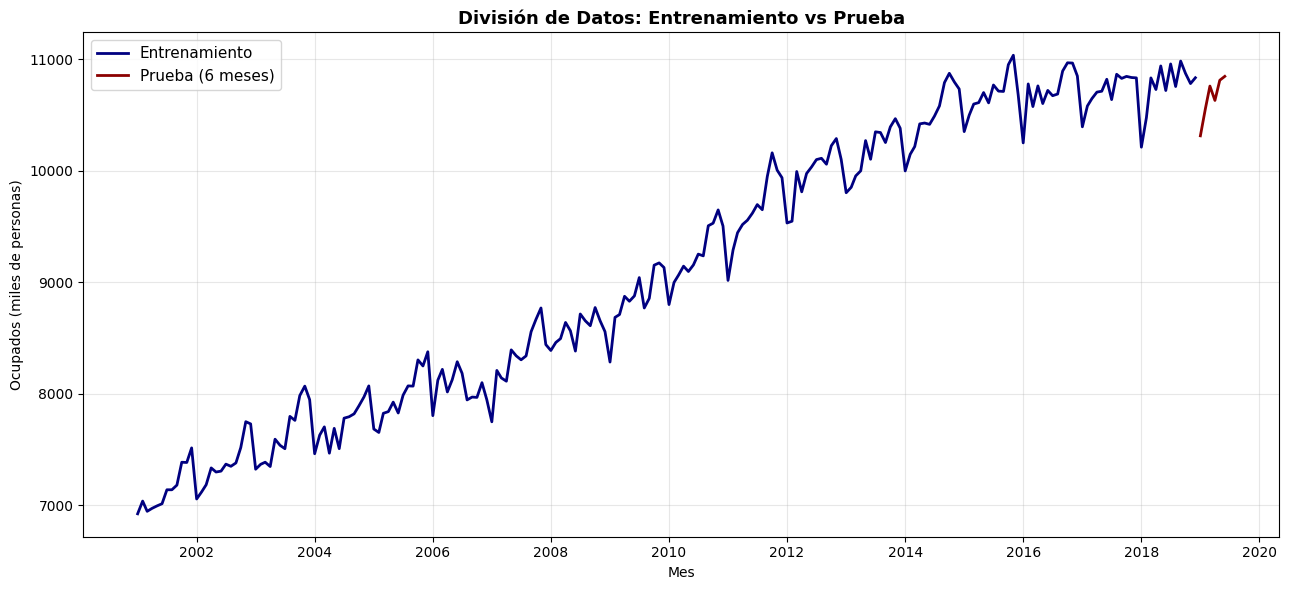

In [147]:
# División Train/Test con los últimos 6 meses como conjunto de prueba
test_size = 6
train_ocupados = ocupados[:-test_size]
test_ocupados = ocupados[-test_size:]

print("=" * 70)
print("PROTOCOLO DE VALIDACIÓN")
print("=" * 70)
print(f"\nConjunto de entrenamiento: {len(train_ocupados)} observaciones")
print(f"Período: {train_ocupados.index[0].date()} a {train_ocupados.index[-1].date()}")
print(f"\nConjunto de prueba: {len(test_ocupados)} observaciones (6 meses)")
print(f"Período: {test_ocupados.index[0].date()} a {test_ocupados.index[-1].date()}")

# Visualizar la división
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train_ocupados.index, train_ocupados.values, linewidth=2, label='Entrenamiento', color='navy')
ax.plot(test_ocupados.index, test_ocupados.values, linewidth=2, label='Prueba (6 meses)', color='darkred')
ax.set_title("División de Datos: Entrenamiento vs Prueba", fontsize=13, fontweight='bold')
ax.set_xlabel("Mes")
ax.set_ylabel("Ocupados (miles de personas)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Implementación de Modelos de Suavización Exponencial


MODELO 1: SUAVIZACIÓN EXPONENCIAL SIMPLE (SES)

Parámetro α (suavización de nivel): 0.633732
RMSE en conjunto de prueba: 253.6373


c:\Users\karol\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


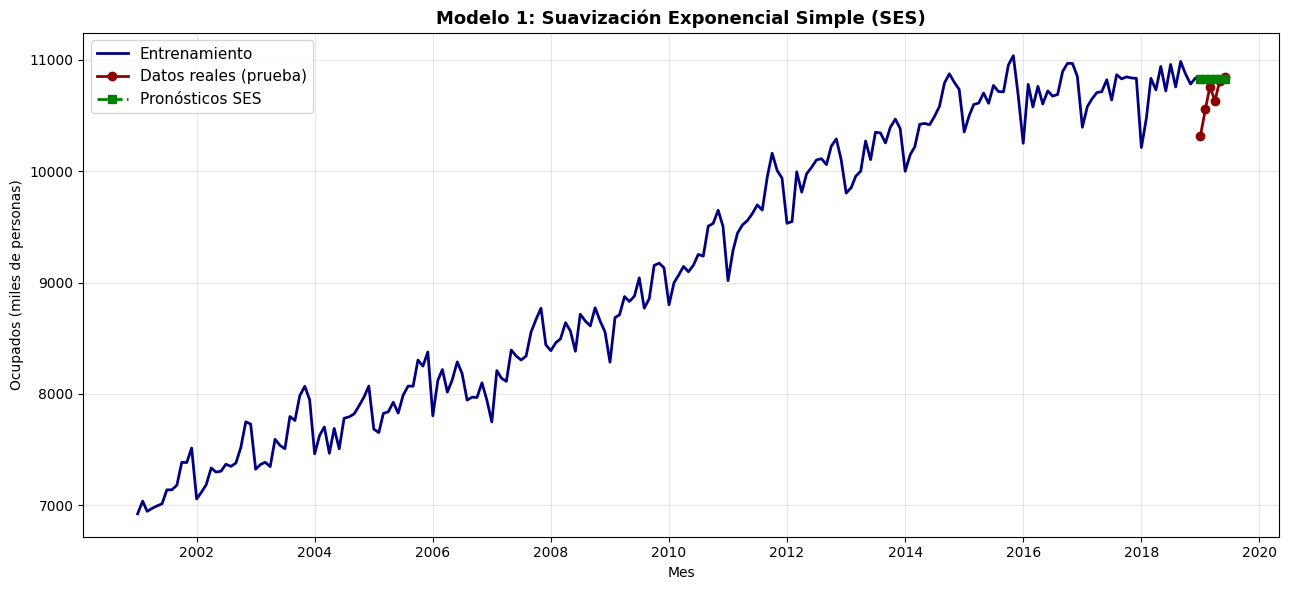

In [148]:
print("\n" + "=" * 70)
print("MODELO 1: SUAVIZACIÓN EXPONENCIAL SIMPLE (SES)")
print("=" * 70)

# Implementar SES
ets_ses = ETSModel(endog=train_ocupados["Ocupados"], error="add")
ets_ses_fit = ets_ses.fit()

# Pronósticos para el conjunto de prueba
pred_ses = ets_ses_fit.forecast(len(test_ocupados))

# Calcular RMSE
rmse_ses = np.sqrt(mean_squared_error(test_ocupados["Ocupados"], pred_ses.values))

# Extraer parámetros
alpha_ses = ets_ses_fit.params.get('smoothing_level', ets_ses_fit.alpha) if hasattr(ets_ses_fit, 'alpha') else ets_ses_fit.params.get('smoothing_level')

print(f"\nParámetro α (suavización de nivel): {alpha_ses:.6f}")
print(f"RMSE en conjunto de prueba: {rmse_ses:.4f}")

# Visualizar
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train_ocupados.index, train_ocupados.values, linewidth=2, label='Entrenamiento', color='navy')
ax.plot(test_ocupados.index, test_ocupados.values, linewidth=2, label='Datos reales (prueba)', color='darkred', marker='o')
ax.plot(test_ocupados.index, pred_ses.values, linewidth=2, label='Pronósticos SES', color='green', linestyle='--', marker='s')
ax.set_title("Modelo 1: Suavización Exponencial Simple (SES)", fontsize=13, fontweight='bold')
ax.set_xlabel("Mes")
ax.set_ylabel("Ocupados (miles de personas)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


MODELO 2: SUAVIZACIÓN EXPONENCIAL LINEAL DE HOLT

Parámetro α (suavización de nivel): 0.572583
Parámetro β (suavización de tendencia): 0.006405
RMSE en conjunto de prueba: 296.1552


c:\Users\karol\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


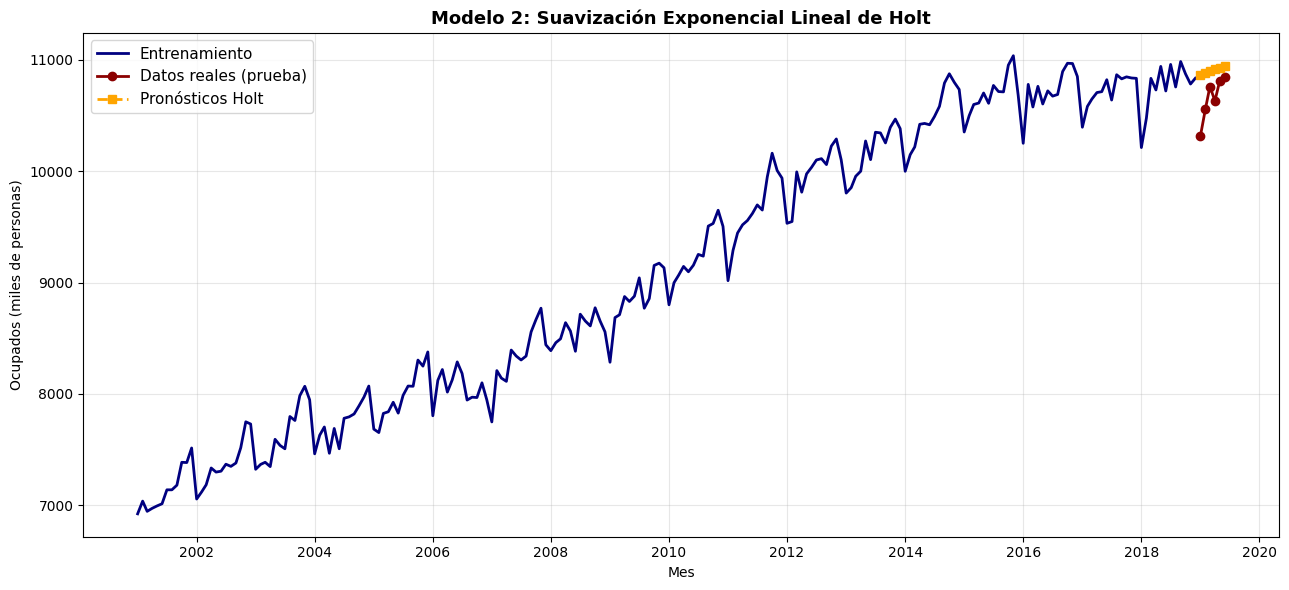

In [149]:
print("\n" + "=" * 70)
print("MODELO 2: SUAVIZACIÓN EXPONENCIAL LINEAL DE HOLT")
print("=" * 70)

# Implementar Holt (con tendencia)
ets_holt = ETSModel(endog=train_ocupados["Ocupados"], error="add", trend="add")
ets_holt_fit = ets_holt.fit()

# Pronósticos para el conjunto de prueba
pred_holt = ets_holt_fit.forecast(len(test_ocupados))

# Calcular RMSE
rmse_holt = np.sqrt(mean_squared_error(test_ocupados["Ocupados"], pred_holt.values))

# Extraer parámetros
alpha_holt = ets_holt_fit.params.get('smoothing_level', ets_holt_fit.alpha) if hasattr(ets_holt_fit, 'alpha') else ets_holt_fit.params.get('smoothing_level')
beta_holt = ets_holt_fit.params.get('smoothing_trend', ets_holt_fit.beta) if hasattr(ets_holt_fit, 'beta') else ets_holt_fit.params.get('smoothing_trend')

print(f"\nParámetro α (suavización de nivel): {alpha_holt:.6f}")
print(f"Parámetro β (suavización de tendencia): {beta_holt:.6f}")
print(f"RMSE en conjunto de prueba: {rmse_holt:.4f}")

# Visualizar
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train_ocupados.index, train_ocupados.values, linewidth=2, label='Entrenamiento', color='navy')
ax.plot(test_ocupados.index, test_ocupados.values, linewidth=2, label='Datos reales (prueba)', color='darkred', marker='o')
ax.plot(test_ocupados.index, pred_holt.values, linewidth=2, label='Pronósticos Holt', color='orange', linestyle='--', marker='s')
ax.set_title("Modelo 2: Suavización Exponencial Lineal de Holt", fontsize=13, fontweight='bold')
ax.set_xlabel("Mes")
ax.set_ylabel("Ocupados (miles de personas)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


MODELO 3A: HOLT-WINTERS ADITIVO


c:\Users\karol\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



Parámetro α (suavización de nivel): 0.524345
Parámetro β (suavización de tendencia): 0.001809
Parámetro γ (suavización estacional): 0.000048
RMSE en conjunto de prueba: 59.6411


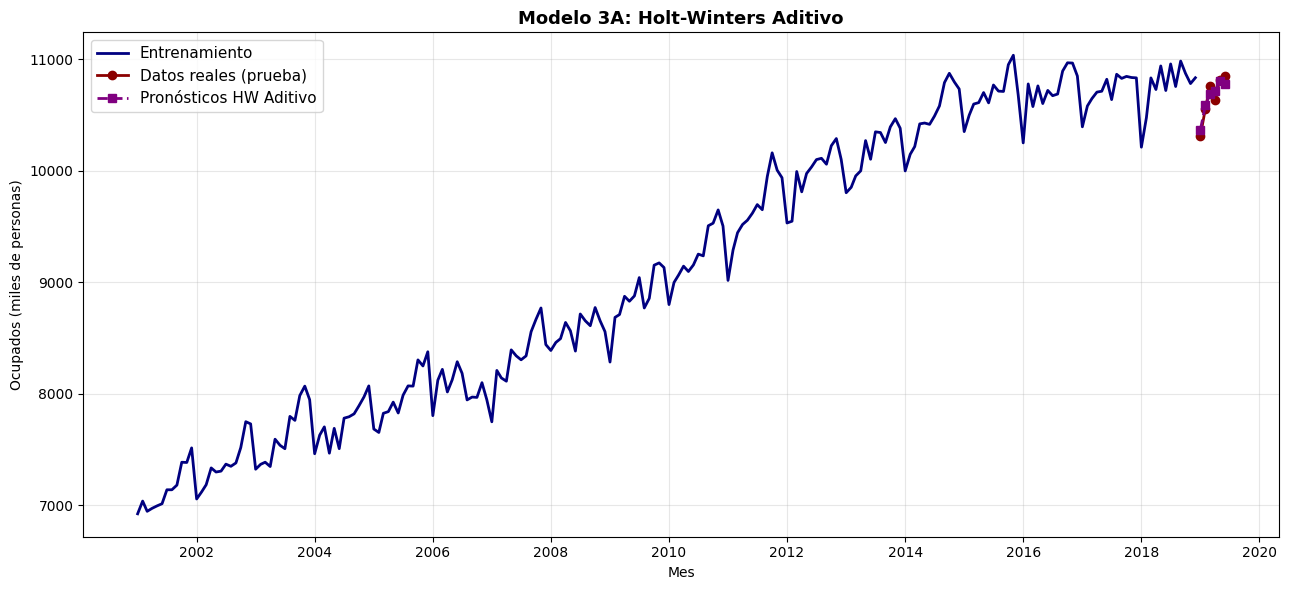

In [150]:
print("\n" + "=" * 70)
print("MODELO 3A: HOLT-WINTERS ADITIVO")
print("=" * 70)

# Implementar Holt-Winters Aditivo (tendencia + estacionalidad)
ets_hw_add = ETSModel(endog=train_ocupados["Ocupados"], error="add", trend="add", seasonal="mul")
ets_hw_add_fit = ets_hw_add.fit()

# Pronósticos para el conjunto de prueba
pred_hw_add = ets_hw_add_fit.forecast(len(test_ocupados))

# Calcular RMSE
rmse_hw_add = np.sqrt(mean_squared_error(test_ocupados["Ocupados"], pred_hw_add.values))

# Extraer parámetros
alpha_hw_add = ets_hw_add_fit.params.get('smoothing_level', ets_hw_add_fit.alpha) if hasattr(ets_hw_add_fit, 'alpha') else ets_hw_add_fit.params.get('smoothing_level')
beta_hw_add = ets_hw_add_fit.params.get('smoothing_trend', ets_hw_add_fit.beta) if hasattr(ets_hw_add_fit, 'beta') else ets_hw_add_fit.params.get('smoothing_trend')
gamma_hw_add = ets_hw_add_fit.params.get('smoothing_seasonal', ets_hw_add_fit.gamma) if hasattr(ets_hw_add_fit, 'gamma') else ets_hw_add_fit.params.get('smoothing_seasonal')

print(f"\nParámetro α (suavización de nivel): {alpha_hw_add:.6f}")
print(f"Parámetro β (suavización de tendencia): {beta_hw_add:.6f}")
print(f"Parámetro γ (suavización estacional): {gamma_hw_add:.6f}")
print(f"RMSE en conjunto de prueba: {rmse_hw_add:.4f}")

# Visualizar
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train_ocupados.index, train_ocupados.values, linewidth=2, label='Entrenamiento', color='navy')
ax.plot(test_ocupados.index, test_ocupados.values, linewidth=2, label='Datos reales (prueba)', color='darkred', marker='o')
ax.plot(test_ocupados.index, pred_hw_add.values, linewidth=2, label='Pronósticos HW Aditivo', color='purple', linestyle='--', marker='s')
ax.set_title("Modelo 3A: Holt-Winters Aditivo", fontsize=13, fontweight='bold')
ax.set_xlabel("Mes")
ax.set_ylabel("Ocupados (miles de personas)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


MODELO 3B: HOLT-WINTERS MULTIPLICATIVO

Parámetro α (suavización de nivel): 0.559443
Parámetro β (suavización de tendencia): 0.000663
Parámetro γ (suavización estacional): 0.000044
RMSE en conjunto de prueba: 61.9885


c:\Users\karol\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


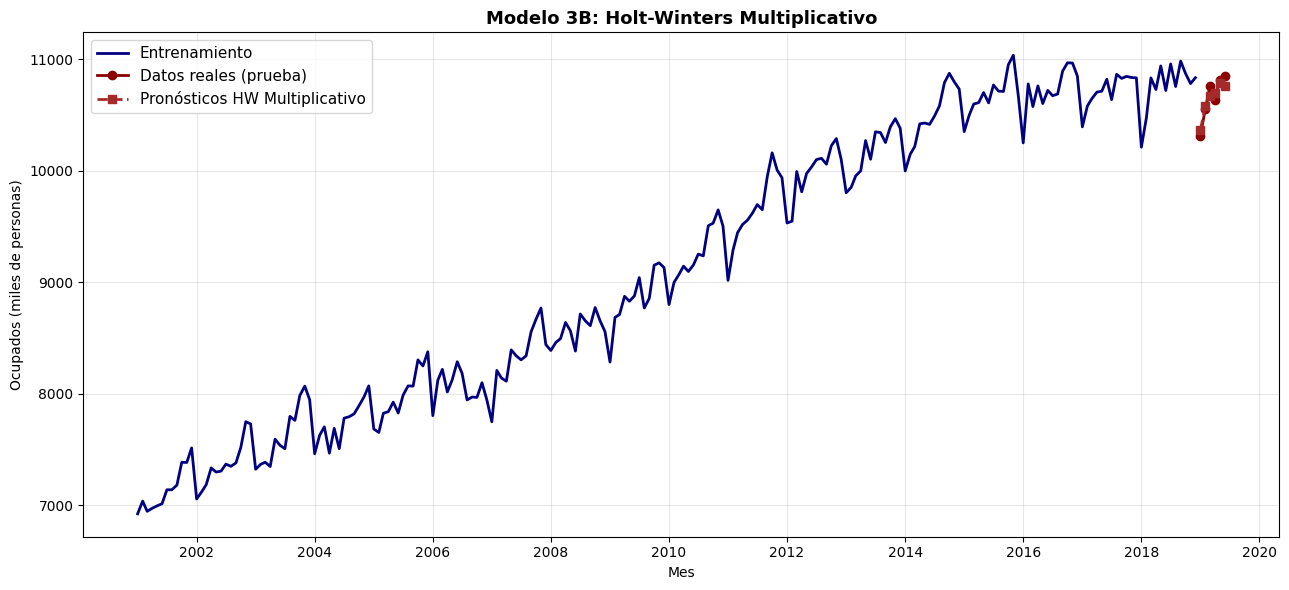

In [151]:
print("\n" + "=" * 70)
print("MODELO 3B: HOLT-WINTERS MULTIPLICATIVO")
print("=" * 70)

# Implementar Holt-Winters Multiplicativo
ets_hw_mul = ETSModel(endog=train_ocupados["Ocupados"], error="mul", trend="add", seasonal="mul")
ets_hw_mul_fit = ets_hw_mul.fit()

# Pronósticos para el conjunto de prueba
pred_hw_mul = ets_hw_mul_fit.forecast(len(test_ocupados))

# Calcular RMSE
rmse_hw_mul = np.sqrt(mean_squared_error(test_ocupados["Ocupados"], pred_hw_mul.values))

# Extraer parámetros
alpha_hw_mul = ets_hw_mul_fit.params.get('smoothing_level', ets_hw_mul_fit.alpha) if hasattr(ets_hw_mul_fit, 'alpha') else ets_hw_mul_fit.params.get('smoothing_level')
beta_hw_mul = ets_hw_mul_fit.params.get('smoothing_trend', ets_hw_mul_fit.beta) if hasattr(ets_hw_mul_fit, 'beta') else ets_hw_mul_fit.params.get('smoothing_trend')
gamma_hw_mul = ets_hw_mul_fit.params.get('smoothing_seasonal', ets_hw_mul_fit.gamma) if hasattr(ets_hw_mul_fit, 'gamma') else ets_hw_mul_fit.params.get('smoothing_seasonal')

print(f"\nParámetro α (suavización de nivel): {alpha_hw_mul:.6f}")
print(f"Parámetro β (suavización de tendencia): {beta_hw_mul:.6f}")
print(f"Parámetro γ (suavización estacional): {gamma_hw_mul:.6f}")
print(f"RMSE en conjunto de prueba: {rmse_hw_mul:.4f}")

# Visualizar
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train_ocupados.index, train_ocupados.values, linewidth=2, label='Entrenamiento', color='navy')
ax.plot(test_ocupados.index, test_ocupados.values, linewidth=2, label='Datos reales (prueba)', color='darkred', marker='o')
ax.plot(test_ocupados.index, pred_hw_mul.values, linewidth=2, label='Pronósticos HW Multiplicativo', color='brown', linestyle='--', marker='s')
ax.set_title("Modelo 3B: Holt-Winters Multiplicativo", fontsize=13, fontweight='bold')
ax.set_xlabel("Mes")
ax.set_ylabel("Ocupados (miles de personas)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Tabla Comparativa de Resultados

In [152]:
print("\n" + "=" * 100)
print("TABLA COMPARATIVA DE MODELOS DE SUAVIZACIÓN EXPONENCIAL")
print("=" * 100)

# Crear dataframe comparativo
resultados_modelos = pd.DataFrame({
    'Modelo': [
        'SES (Simple)',
        'Holt (Lineal)',
        'HW Aditivo',
        'HW Multiplicativo'
    ],
    'α (Nivel)': [
        f"{alpha_ses:.6f}",
        f"{alpha_holt:.6f}",
        f"{alpha_hw_add:.6f}",
        f"{alpha_hw_mul:.6f}"
    ],
    'β (Tendencia)': [
        '—',
        f"{beta_holt:.6f}",
        f"{beta_hw_add:.6f}",
        f"{beta_hw_mul:.6f}"
    ],
    'γ (Estacional)': [
        '—',
        '—',
        f"{gamma_hw_add:.6f}",
        f"{gamma_hw_mul:.6f}"
    ],
    'RMSE (Test)': [
        f"{rmse_ses:.4f}",
        f"{rmse_holt:.4f}",
        f"{rmse_hw_add:.4f}",
        f"{rmse_hw_mul:.4f}"
    ]
})

print("\n")
print(resultados_modelos.to_string(index=False))
print("\n" + "=" * 100)

# Identificar el mejor modelo
rmse_values = [rmse_ses, rmse_holt, rmse_hw_add, rmse_hw_mul]
model_names = ['SES', 'Holt', 'HW Aditivo', 'HW Multiplicativo']
best_idx = np.argmin(rmse_values)
best_model = model_names[best_idx]
best_rmse = rmse_values[best_idx]

print(f"\n✓ MEJOR MODELO: {best_model} con RMSE = {best_rmse:.4f}")
print("=" * 100)


TABLA COMPARATIVA DE MODELOS DE SUAVIZACIÓN EXPONENCIAL


           Modelo α (Nivel) β (Tendencia) γ (Estacional) RMSE (Test)
     SES (Simple)  0.633732             —              —    253.6373
    Holt (Lineal)  0.572583      0.006405              —    296.1552
       HW Aditivo  0.524345      0.001809       0.000048     59.6411
HW Multiplicativo  0.559443      0.000663       0.000044     61.9885


✓ MEJOR MODELO: HW Aditivo con RMSE = 59.6411


### 5.5 Pronósticos Finales para los Próximos 6 Meses (Usando Modelo Ganador)

In [153]:
# Seleccionar el modelo ganador y entrenar con TODO el dataset
print("\n" + "=" * 100)
print(f"PRONÓSTICOS FINALES - MODELO GANADOR: {best_model.upper()}")
print("=" * 100)

# Configuración según el modelo ganador
if best_model == "SES":
    nombre_modelo = "Suavización Exponencial Simple"
    final_model = ETSModel(endog=ocupados["Ocupados"], error="add")
    
    alpha_final = alpha_ses
    beta_final = None
    gamma_final = None
    rmse_final = rmse_ses

elif best_model == "Holt":
    nombre_modelo = "Holt Lineal"
    final_model = ETSModel(endog=ocupados["Ocupados"], error="add", trend="add")
    
    alpha_final = alpha_holt
    beta_final = beta_holt
    gamma_final = None
    rmse_final = rmse_holt

elif best_model == "HW Aditivo":
    nombre_modelo = "Holt-Winters Aditivo"
    final_model = ETSModel(endog=ocupados["Ocupados"], error="add", trend="add", seasonal="mul")
    
    alpha_final = alpha_hw_add
    beta_final = beta_hw_add
    gamma_final = gamma_hw_add
    rmse_final = rmse_hw_add

else:
    nombre_modelo = "Holt-Winters Multiplicativo"
    final_model = ETSModel(endog=ocupados["Ocupados"], error="mul", trend="add", seasonal="mul")
    
    alpha_final = alpha_hw_mul
    beta_final = beta_hw_mul
    gamma_final = gamma_hw_mul
    rmse_final = rmse_hw_mul


# Ajustar modelo ganador con todo el dataset
print(f"\nEntrenando con {nombre_modelo} en TODO el dataset...")

final_fit = final_model.fit()

print(f"✓ Modelo ajustado exitosamente con TODO el dataset ({len(ocupados)} observaciones)")

# Mostrar parámetros del modelo ganador evaluado
print("\nParámetros del modelo ganador:")
print(f"  α (Nivel): {alpha_final:.6f}")

if beta_final is not None:
    print(f"  β (Tendencia): {beta_final:.6f}")

if gamma_final is not None:
    print(f"  γ (Estacional): {gamma_final:.6f}")

print(f"\nRMSE del modelo ganador en prueba: {rmse_final:.4f}")


# Generar pronósticos para los próximos 6 meses
forecast_steps = 6
forecast_final = final_fit.forecast(steps=forecast_steps)

# Crear fechas futuras
future_dates = pd.date_range(
    start=ocupados.index[-1] + pd.DateOffset(months=1),
    periods=forecast_steps,
    freq="MS"
)

# Crear tabla final de pronósticos
pronosticos_df = pd.DataFrame({
    "Pronóstico": forecast_final.values
}, index=future_dates)

pronosticos_df.index.name = "Fecha"

print("\n" + "=" * 70)
print("PRONÓSTICOS PARA LOS PRÓXIMOS 6 MESES")
print("=" * 70)
print(pronosticos_df.to_string())
print("=" * 70)


PRONÓSTICOS FINALES - MODELO GANADOR: HW ADITIVO

Entrenando con Holt-Winters Aditivo en TODO el dataset...
✓ Modelo ajustado exitosamente con TODO el dataset (222 observaciones)

Parámetros del modelo ganador:
  α (Nivel): 0.524345
  β (Tendencia): 0.001809
  γ (Estacional): 0.000048

RMSE del modelo ganador en prueba: 59.6411

PRONÓSTICOS PARA LOS PRÓXIMOS 6 MESES
              Pronóstico
Fecha                   
2019-07-01  10915.496855
2019-08-01  10903.946509
2019-09-01  10997.498116
2019-10-01  11140.191571
2019-11-01  11165.265876
2019-12-01  11069.602895


c:\Users\karol\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


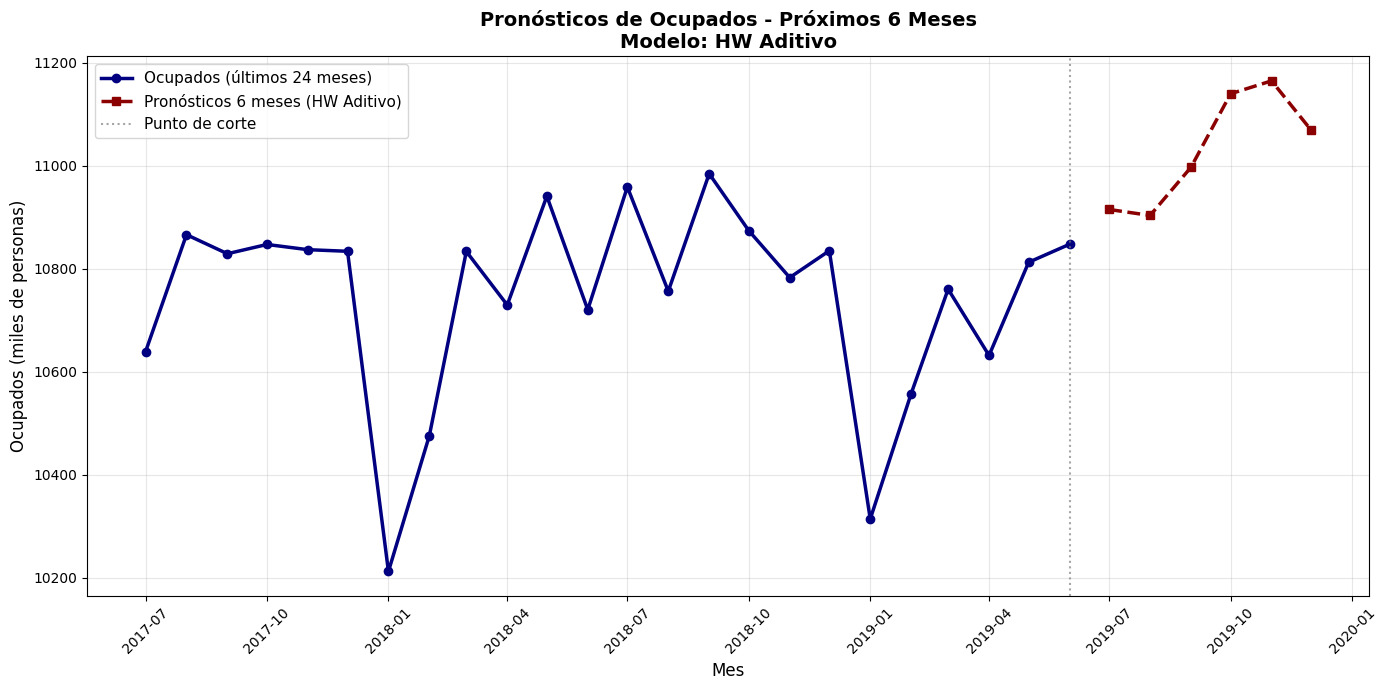

In [154]:
# Visualizar serie histórica + pronósticos
fig, ax = plt.subplots(figsize=(14, 7))

# Últimos 24 meses de la serie histórica para mejor visualización
ax.plot(ocupados.index[-24:], ocupados.values[-24:], linewidth=2.5, label='Ocupados (últimos 24 meses)', color='navy', marker='o')
ax.plot(pronosticos_df.index, pronosticos_df.values, linewidth=2.5, label=f'Pronósticos 6 meses ({best_model})', color='darkred', marker='s', linestyle='--')

ax.axvline(x=ocupados.index[-1], color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='Punto de corte')
ax.set_title(f"Pronósticos de Ocupados - Próximos 6 Meses\nModelo: {best_model}", fontsize=14, fontweight='bold')
ax.set_xlabel("Mes", fontsize=12)
ax.set_ylabel("Ocupados (miles de personas)", fontsize=12)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.6 Recomendaciones y Limitaciones de los Pronósticos

In [155]:
print("\n" + "=" * 100)
print("LIMITACIONES DE LOS PRONÓSTICOS")
print("=" * 100)

limitaciones = """
1. **Horizonte de Pronóstico Corto (6 meses):**
   - Los pronósticos a corto plazo son más confiables que a largo plazo
   - Se asume que los patrones históricos se mantienen en el futuro próximo
   - Cambios estructurales en el mercado laboral podrían reducir la precisión

2. **Dependencia de Patrones Históricos:**
   - El modelo se basa en la relación temporal observada en los datos
   - Shocks externos (crisis económicas, pandemia, reformas laborales) no son capturados
   - La estacionariedad de la serie asume volatilidad constante

3. **Falta de Variables Exógenas:**
   - No se incluyen variables explicativas (crecimiento PIB, políticas fiscales, inflación)
   - Eventos macroeconómicos no previstos podrían afectar significativamente el resultado

4. **Calidad de los Datos:**
   - Se asume que los datos son precisos y completos
   - Cambios en metodología de recolección de datos podrían afectar la serie

5. **Validación con Período Limitado:**
   - El RMSE se calculó solo con 6 observaciones de prueba
   - Muestras pequeñas pueden llevar a estimaciones de error poco estables

6. **Pérdida de Información Prospectiva:**
   - El modelo no incorpora expectativas futuras de analistas o agentes económicos
   - No captura tendencias de mediano plazo relacionadas con ciclos económicos
"""

print(limitaciones)

print("\n" + "=" * 100)
print("RECOMENDACIONES PARA EL USO DE LOS PRONÓSTICOS")
print("=" * 100)

recomendaciones = """
1. **Usar como Referencia Base, No como Predicción Exacta:**
   - Los pronósticos deben servir como punto de partida para análisis adicionales
   - Complementar con criterio experto y análisis cualitativo del mercado laboral

2. **Monitoreo Continuo:**
   - Comparar los valores reales con los pronósticos conforme se disponga de nueva información
   - Actualizar el modelo mensualmente con datos recientes

3. **Intervalos de Confianza:**
   - Considerar márgenes de error del ±{best_rmse:.4f} miles de personas
   - Los verdaderos valores podrían estar fuera de los puntos estimados

4. **Análisis de Escenarios:**
   - Desarrollar pronósticos alternativos bajo diferentes supuestos económicos
   - Evaluar casos de optimismo, pesimismo y base

5. **Validación Cruzada:**
   - A medida que se observe el desempeño real, comparar con otros métodos
   - Si el desempeño es pobre, explorar especificaciones alternativas

6. **Comunicación de Incertidumbre:**
   - Explicitar los supuestos del modelo al comunicar los resultados
   - Enfatizar que es un pronóstico probabilístico, no determinístico

7. **Integración con Información Cualitativa:**
   - Combinar con encuestas de expectativas empresariales
   - Considerar noticias de política laboral y condiciones macroeconómicas
"""

print(recomendaciones)
print("\n" + "=" * 100)


LIMITACIONES DE LOS PRONÓSTICOS

1. **Horizonte de Pronóstico Corto (6 meses):**
   - Los pronósticos a corto plazo son más confiables que a largo plazo
   - Se asume que los patrones históricos se mantienen en el futuro próximo
   - Cambios estructurales en el mercado laboral podrían reducir la precisión

2. **Dependencia de Patrones Históricos:**
   - El modelo se basa en la relación temporal observada en los datos
   - Shocks externos (crisis económicas, pandemia, reformas laborales) no son capturados
   - La estacionariedad de la serie asume volatilidad constante

3. **Falta de Variables Exógenas:**
   - No se incluyen variables explicativas (crecimiento PIB, políticas fiscales, inflación)
   - Eventos macroeconómicos no previstos podrían afectar significativamente el resultado

4. **Calidad de los Datos:**
   - Se asume que los datos son precisos y completos
   - Cambios en metodología de recolección de datos podrían afectar la serie

5. **Validación con Período Limitado:**
   - 